In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np


# Path to your log file
log_file_list = ['../work/experiments/stellar-core/cp_4/tsm-sc-001/node2/stellar-core.log', \
                '../work/experiments/stellar-core/cp_8/tsm-sc-001/node2/stellar-core.log', \
                '../work/experiments/stellar-core/cp_16/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/cp_48/tsm-sc-001/node2/stellar-core.log', ]


for log_file in log_file_list:
    print(log_file)
    # Regex patterns
    propose_pattern = re.compile(r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*Received PROPOSE block (\w+) at view (\d+)")
    commit_pattern  = re.compile(r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*Committed block (\w+) at view (\d+)")
    
    # Dictionaries to hold times
    propose_times = {}
    commit_times = {}
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                propose_times[(block, view)] = ts
            
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                commit_times[(block, view)] = ts
    
    # Match proposals to commits → compute latency
    latencies = []
    commit_timestamps = []
    for key, ctime in commit_times.items():
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            latencies.append({
                "block": key[0],
                "view": key[1],
                "commit_time": ctime,
                "latency": latency
            })
            commit_timestamps.append(ctime)
    
    if not commit_timestamps:
        print("No commits found.")
        exit()
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    commit_seconds = [(t - start_time).total_seconds() for t in commit_timestamps]
    
    # DataFrame for throughput
    df = pd.DataFrame({"time_sec": commit_seconds, "count": 1})
    df.set_index("time_sec", inplace=True)
    
    # Throughput = commits per second (resampled)
    throughput = df["count"].groupby(df.index.round()).sum()
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (blocks/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Blocks/sec")
    # plt.title("Throughput vs Time")
    # # plt.grid(True)
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("throughput.png", dpi=150)
    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(lat_df["time_sec"], lat_df["latency"], "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")
    # plt.title("Proposal → Commit Latency")
    # # plt.grid(True)
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("latency.png", dpi=150)
    # plt.show()
    print(np.average(throughput.values[-60:]))
    print(np.average(np.array(lat_df["latency"])[-60:]))

../work/experiments/stellar-core/cp_4/tsm-sc-001/node2/stellar-core.log
72.48333333333333
0.003
../work/experiments/stellar-core/cp_8/tsm-sc-001/node2/stellar-core.log
69.16666666666667
0.0019500000000000001
../work/experiments/stellar-core/cp_16/tsm-sc-001/node2/stellar-core.log
54.11666666666667
0.005100000000000001
../work/experiments/stellar-core/cp_48/tsm-sc-001/node2/stellar-core.log
18.783333333333335
0.010683333333333333


Processing: ../work/experiments/stellar-core/collection_4/tsm-sc-001/node2/stellar-core.log
Total proposals received: 12028
Total commits: 11526
COLLECT views found: 695
Normal consensus commits: 10130


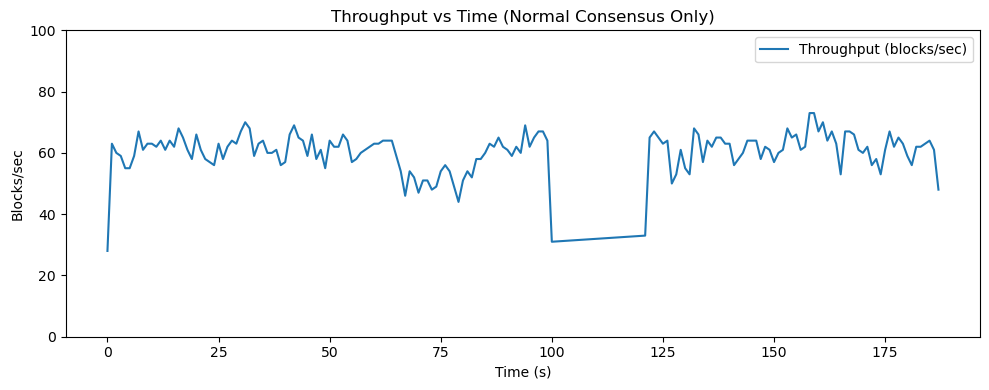

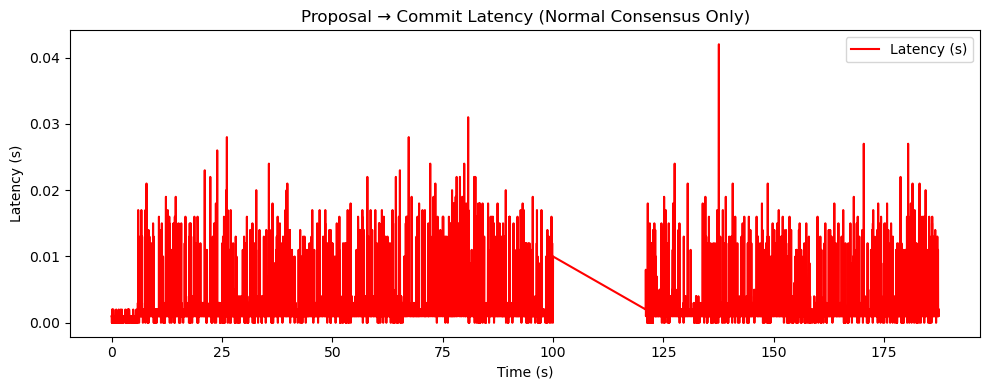


=== STATISTICS (Last 60 commits) ===
Average throughput: 61.92 blocks/sec
Average latency: 0.0025 sec
Average latency: 2.45 ms

=== OVERALL STATISTICS ===
Average throughput: 60.30 blocks/sec
Average latency: 0.0021 sec
Average latency: 2.13 ms
Min latency: 0.00 ms
Max latency: 42.00 ms
Processing: ../work/experiments/stellar-core/collection_8/tsm-sc-001/node2/stellar-core.log
Total proposals received: 7748
Total commits: 7755
COLLECT views found: 316
Normal consensus commits: 7007


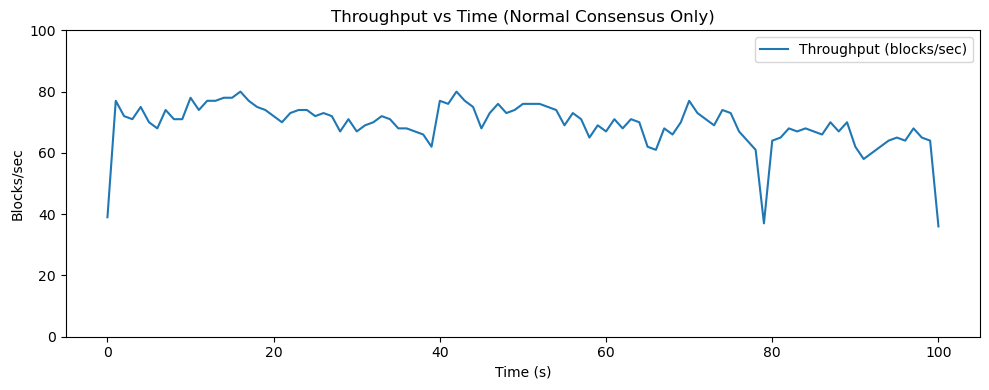

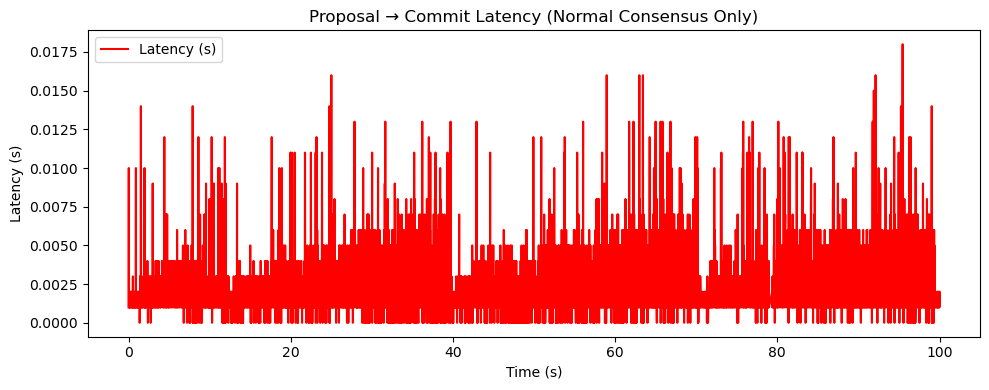


=== STATISTICS (Last 60 commits) ===
Average throughput: 67.93 blocks/sec
Average latency: 0.0017 sec
Average latency: 1.70 ms

=== OVERALL STATISTICS ===
Average throughput: 69.38 blocks/sec
Average latency: 0.0022 sec
Average latency: 2.20 ms
Min latency: 0.00 ms
Max latency: 18.00 ms


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file


# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_4/tsm-sc-001/node2/stellar-core.log', \
                '../work/experiments/stellar-core/collection_8/tsm-sc-001/node2/stellar-core.log']

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # Regex patterns
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+)"
    )
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times
    propose_times = {}
    commit_times = {}
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                commit_times[(block, view)] = ts
    
    print(f"Total proposals received: {len(propose_times)}")
    print(f"Total commits: {len(commit_times)}")
    print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency
            })
            commit_timestamps.append(ctime)
    
    if not commit_timestamps:
        print("No normal consensus commits found.")
        continue
    
    print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    commit_seconds = [(t - start_time).total_seconds() for t in commit_timestamps]
    
    # DataFrame for throughput
    df = pd.DataFrame({"time_sec": commit_seconds, "count": 1})
    df.set_index("time_sec", inplace=True)
    
    # Throughput = commits per second (resampled)
    throughput = df["count"].groupby(df.index.round()).sum()
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index, throughput.values, "-", label="Throughput (blocks/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Blocks/sec")
    plt.ylim(0,100)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(lat_df["time_sec"], lat_df["latency"], "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()
    
    # ---- Statistics ----
    print(f"\n=== STATISTICS (Last 60 commits) ===")
    print(f"Average throughput: {np.average(throughput.values[-60:]):.2f} blocks/sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]):.4f} sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]) * 1000:.2f} ms")
    
    print(f"\n=== OVERALL STATISTICS ===")
    print(f"Average throughput: {np.average(throughput.values):.2f} blocks/sec")
    print(f"Average latency: {np.average(lat_df['latency']):.4f} sec")
    print(f"Average latency: {np.average(lat_df['latency']) * 1000:.2f} ms")
    print(f"Min latency: {np.min(lat_df['latency']) * 1000:.2f} ms")
    print(f"Max latency: {np.max(lat_df['latency']) * 1000:.2f} ms")

# for log_file in log_file_list:
#     print(log_file)
#     # Regex patterns
#     propose_pattern = re.compile(r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*Received PROPOSE block (\w+) at view (\d+)")
#     commit_pattern  = re.compile(r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*Committed block (\w+) at view (\d+)")
    
#     # Dictionaries to hold times
#     propose_times = {}
#     commit_times = {}
    
#     # Parse log file
#     with open(log_file) as f:
#         for line in f:
#             pmatch = propose_pattern.search(line)
#             if pmatch:
#                 ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
#                 block = pmatch.group(2)
#                 view = int(pmatch.group(3))
#                 propose_times[(block, view)] = ts
            
#             cmatch = commit_pattern.search(line)
#             if cmatch:
#                 ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
#                 block = cmatch.group(2)
#                 view = int(cmatch.group(3))
#                 commit_times[(block, view)] = ts
    
#     # Match proposals to commits → compute latency
#     latencies = []
#     commit_timestamps = []
#     for key, ctime in commit_times.items():
#         if key in propose_times:
#             latency = (ctime - propose_times[key]).total_seconds()
#             latencies.append({
#                 "block": key[0],
#                 "view": key[1],
#                 "commit_time": ctime,
#                 "latency": latency
#             })
#             commit_timestamps.append(ctime)
    
#     if not commit_timestamps:
#         print("No commits found.")
#         exit()
    
#     # Normalize times to seconds since start
#     start_time = min(commit_timestamps + list(propose_times.values()))
#     commit_seconds = [(t - start_time).total_seconds() for t in commit_timestamps]
    
#     # DataFrame for throughput
#     df = pd.DataFrame({"time_sec": commit_seconds, "count": 1})
#     df.set_index("time_sec", inplace=True)
    
#     # Throughput = commits per second (resampled)
#     throughput = df["count"].groupby(df.index.round()).sum()
    
#     # DataFrame for latencies
#     lat_df = pd.DataFrame(latencies)
#     lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    
#     # ---- Plot Throughput ----
#     plt.figure(figsize=(10, 4))
#     plt.plot(throughput.index, throughput.values, "-", label="Throughput (blocks/sec)")
    
#     plt.xlabel("Time (s)")
#     plt.ylabel("Blocks/sec")
#     plt.title("Throughput vs Time")
#     # plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig("throughput.png", dpi=150)
#     plt.show()
    
#     # ---- Plot Latency ----
#     plt.figure(figsize=(10, 4))
#     plt.plot(lat_df["time_sec"], lat_df["latency"], "-", color="r", label="Latency (s)")
#     plt.xlabel("Time (s)")
#     plt.ylabel("Latency (s)")
#     plt.title("Proposal → Commit Latency")
#     # plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig("latency.png", dpi=150)
#     plt.show()
#     print(np.average(throughput.values[-60:]))
#     print(np.average(np.array(lat_df["latency"])[-60:]))

In [5]:
throughput

54.55636446667623